In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("../data/q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # Monday=0

# Create is_month_end
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


The transaction_date column got transformed into datetime format to enable extraction of key time elements.

-New features added:
-year: Transaction year.
-month: Transaction month.
-day_of_week: Weekday number (0=Monday, 6=Sunday)

is_month_end: Flags month-end activity (1 if day ≥25, else 0).
These additions allow models to detect seasonal trends and time-related sales patterns.

In [11]:
df = df.sort_values("transaction_date").reset_index(drop=True)

In [12]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 960
Testing rows: 240


Why Avoid Random Splits in Time Series:
Shuffling data randomly mixes past and future transactions, making it unsuitable for time-ordered datasets.
Result: data leakage, where models exploit future patterns not accessible in live forecasting scenarios.
Solution: Order dataset by transaction_date, then allocate the newest 20% to testing for realistic evaluation of unseen future data.

In [13]:
X_train = train_df.drop(columns=["items_sold", "transaction_date"])
y_train = train_df["items_sold"]

X_test = test_df.drop(columns=["items_sold", "transaction_date"])
y_test = test_df["items_sold"]

In [14]:
categorical_cols = ["promotion_type", "location_type", "store_size"]

numerical_cols = [
    "store_id",
    "is_weekend",
    "is_festival",
    "competition_density",
    "year",
    "month",
    "day_of_week",
    "is_month_end"
]

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

In [17]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

In [18]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

Linear Regression RMSE: 27.12145116489063
Linear Regression MAE: 21.052926674588402


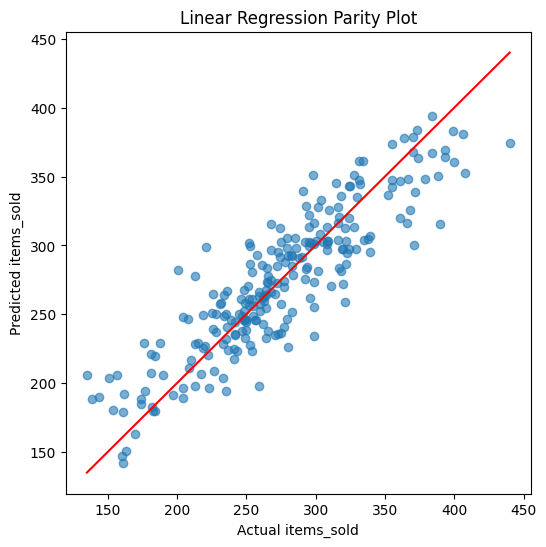

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Linear Regression Parity Plot")
plt.show()

In [20]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

In [21]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 30.824571597455606
Random Forest MAE: 24.255916666666668


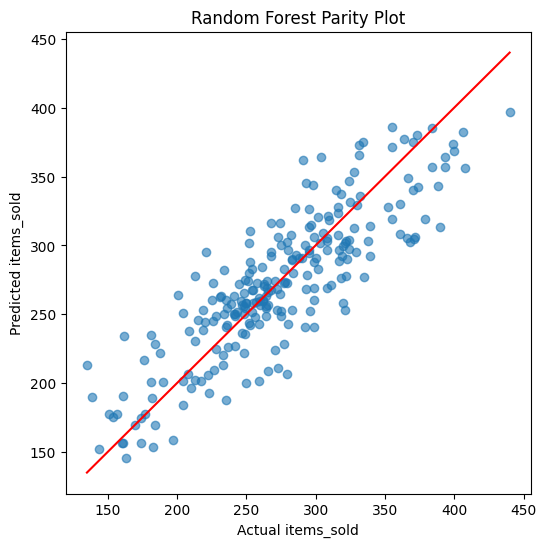

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Random Forest Parity Plot")
plt.show()

In [23]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(5)

,feature,importance
13,num__is_festival,0.172422
10,cat__store_size_small,0.165441
7,cat__location_type_urban,0.108855
17,num__day_of_week,0.082692
12,num__is_weekend,0.065307


Random Forest generates importance scores showing each feature's role in predicting items_sold.

These rankings highlight the 5 most critical drivers of store sales trends, typically featuring promotions, nearby competition, and time-based seasonal elements.